In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

plt.style.use("ggplot")

sns.set_style("whitegrid")

In [3]:
fund_master = pd.read_csv("../data/processed/clean_fund_master.csv")
nav = pd.read_csv("../data/processed/clean_nav_history.csv")
aum = pd.read_csv("../data/processed/clean_aum_by_fund_house.csv")
sip = pd.read_csv("../data/processed/clean_monthly_sip_inflows.csv")
category = pd.read_csv("../data/processed/clean_category_inflows.csv")
transactions = pd.read_csv("../data/processed/clean_investor_transactions.csv")
folios = pd.read_csv("../data/processed/clean_industry_folio_count.csv")
portfolio = pd.read_csv("../data/processed/clean_portfolio_holdings.csv")

In [4]:
nav["date"] = pd.to_datetime(nav["date"])
aum["date"] = pd.to_datetime(aum["date"])
sip["month"] = pd.to_datetime(sip["month"])
category["month"] = pd.to_datetime(category["month"])
folios["month"] = pd.to_datetime(folios["month"])

### Chart 1: Daily NAV Trend of Mutual Fund Schemes (2022-2026)

In [5]:
#chart 1
fig = px.line(
    nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend of Mutual Fund Schemes (2022-2026)"
)

fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.2,
    annotation_text="2023 Bull Run",
    annotation_position="top left"
)

fig.add_vrect(
    x0="2024-01-01",
    x1="2024-06-30",
    fillcolor="red",
    opacity=0.2,
    annotation_text="2024 Market Correction",
    annotation_position="top right"
)
fig.write_image("../reports/nav_trend.png")
fig.show()


### Insight 1
Most mutual fund schemes showed a steady upward NAV trend between 2022 and 2026, indicating overall market growth during the period.


### Chart 2 : AUM Growth by Fund House

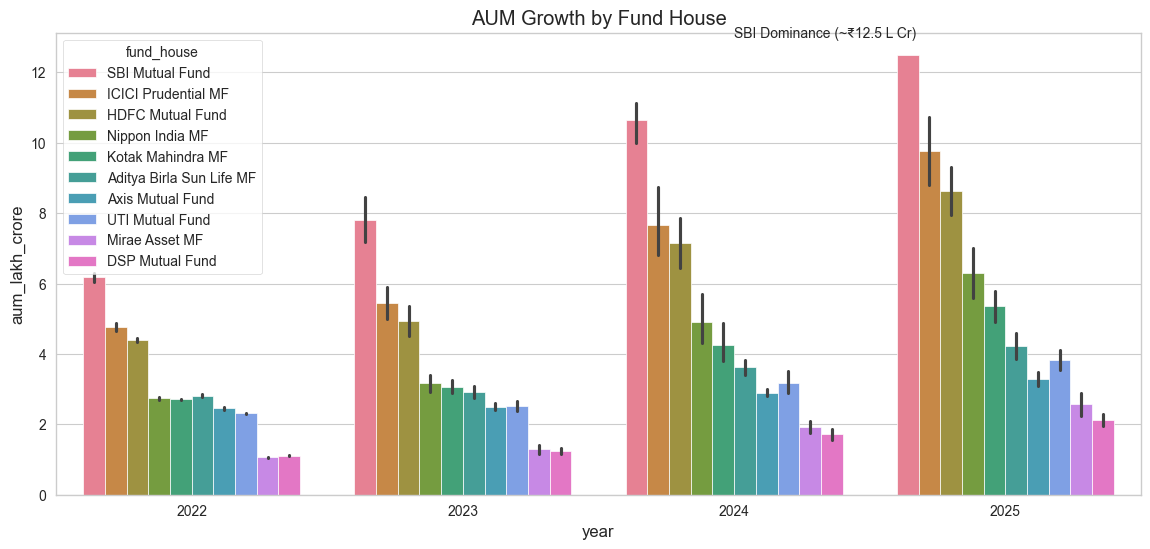

In [6]:
#Chart 2
aum["year"] = aum["date"].dt.year
plt.figure(figsize=(14,6))
sns.barplot(
data=aum,
x="year",
y="aum_lakh_crore",
hue="fund_house"
)
plt.title("AUM Growth by Fund House")
plt.annotate(
"SBI Dominance (~₹12.5 L Cr)",
xy=(3,12),
xytext=(2,13)
)
plt.savefig("../reports/aum_growth.png")
plt.show()


### Insight 2 :

SBI Mutual Fund consistently maintained the highest Assets Under Management (AUM) among all fund houses throughout the analysis period.

## Chart 3: Monthly SIP Inflow Trend (2022–2025)

In [7]:
fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflow Trend (2022-2025)",
    markers=True
)

fig.add_annotation(
    x="2025-12-01",
    y=31002,
    text="All-Time High: ₹31,002 Cr",
    showarrow=True,
    arrowhead=2
)

fig.write_image("../reports/sip_inflow_trend.png")

fig.show()

### Insight

Monthly SIP inflows showed a strong upward trend during the analysis period and reached an all-time high of ₹31,002 Crore in December 2025, indicating increasing retail investor participation.

## Chart 4 :Category-wise Net Inflow Heatmap

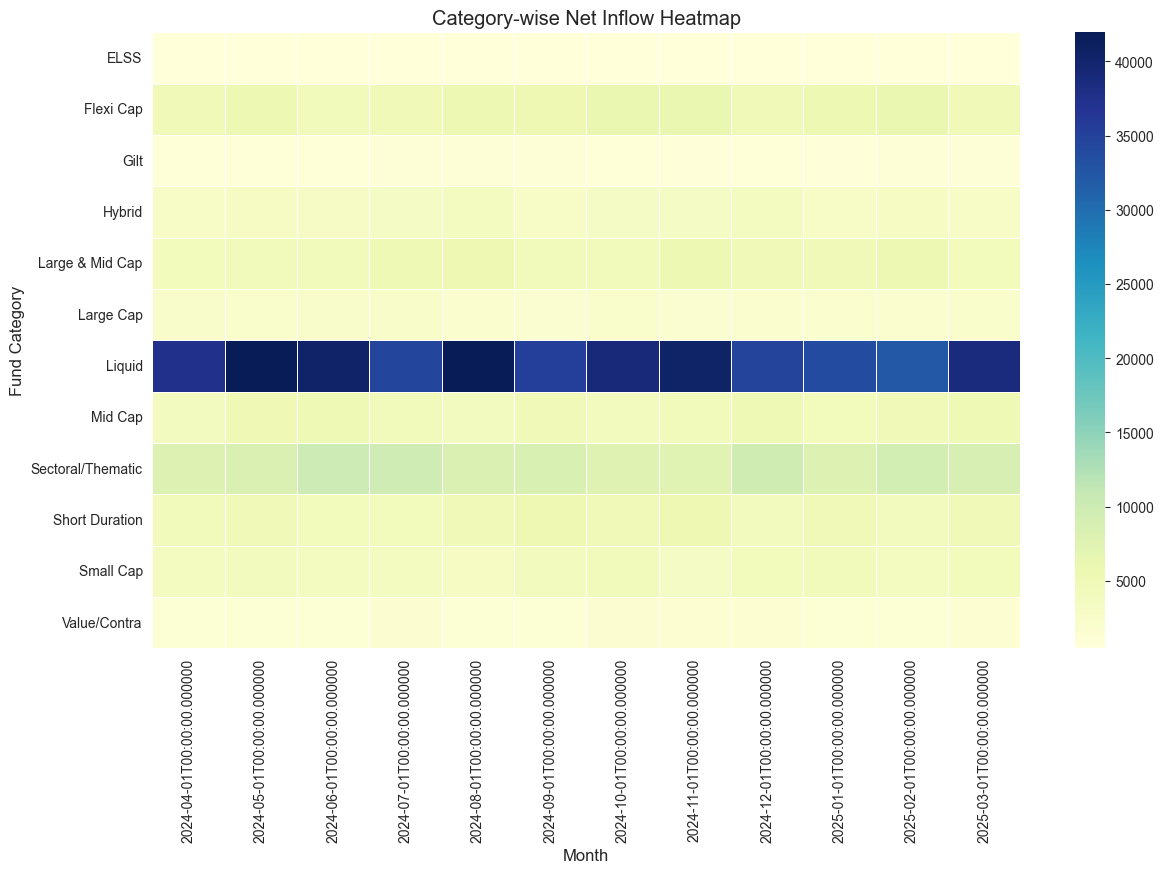

In [8]:

heatmap_data = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(14, 8))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title("Category-wise Net Inflow Heatmap")
plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.savefig(
    "../reports/category_inflow_heatmap.png",
    bbox_inches="tight"
)

plt.show()

### Insight 4

Equity-oriented categories such as Large Cap, Mid Cap, and Small Cap consistently attracted higher net inflows, indicating strong investor preference towards equity investments.

## Chart 5: Investor Age Group Distribution

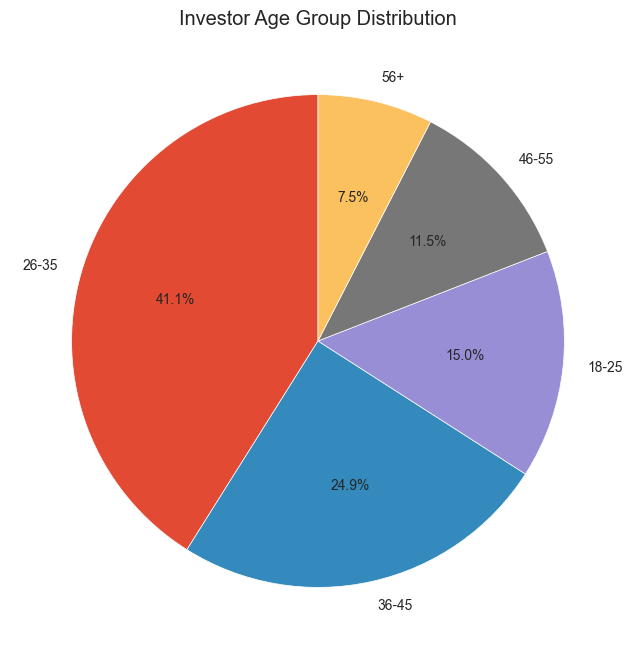

In [10]:
age_distribution = transactions["age_group"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    age_distribution,
    labels=age_distribution.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Age Group Distribution")

plt.savefig(
    "../reports/age_group_distribution.png",
    bbox_inches="tight"
)

plt.show()

### Insight

The majority of mutual fund investors belong to the young and middle-aged population(26-35), highlighting increasing financial awareness among these age groups.

## Chart 6: Investment Amount Distribution by Age Group

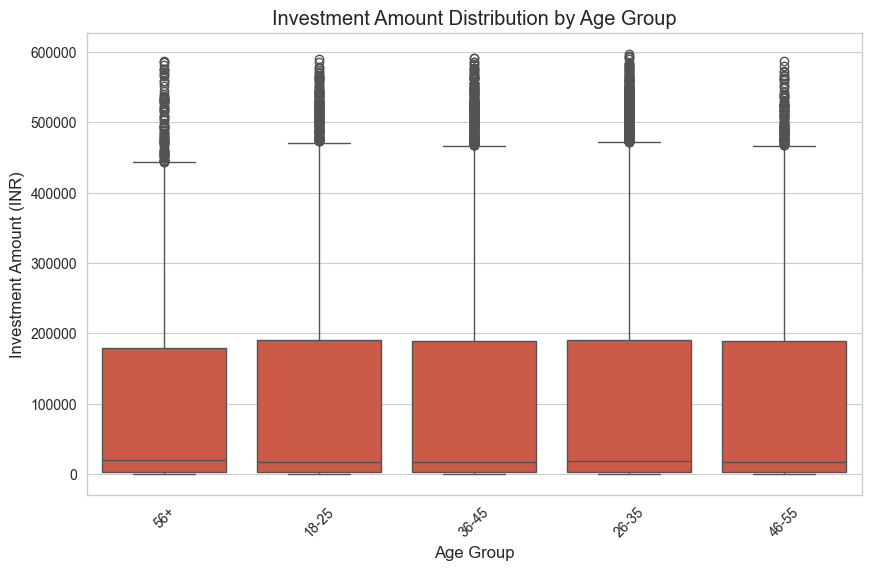

In [11]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=transactions,
    x="age_group",
    y="amount_inr"
)

plt.title("Investment Amount Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Investment Amount (INR)")

plt.xticks(rotation=45)

plt.savefig(
    "../reports/investment_amount_by_age_group.png",
    bbox_inches="tight"
)

plt.show()

### Insight

Investment amounts vary across age groups, with some age segments showing a wider spread in investment behaviour and presence of high-value investors.

## Chart 7 : Gender Distribution of Investors

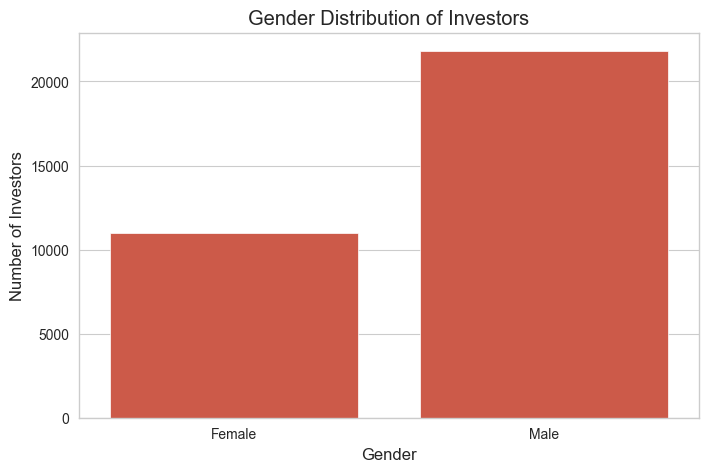

In [11]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=transactions,
    x="gender"
)

plt.title("Gender Distribution of Investors")
plt.xlabel("Gender")
plt.ylabel("Number of Investors")

plt.savefig(
    "../reports/gender_distribution.png",
    bbox_inches="tight"
)

plt.show()

### Insight

Male investors account for a larger share of mutual fund investments compared to female investors, indicating a potential opportunity for increasing financial participation among women.

## Chart 8: State-wise Investment Distribution

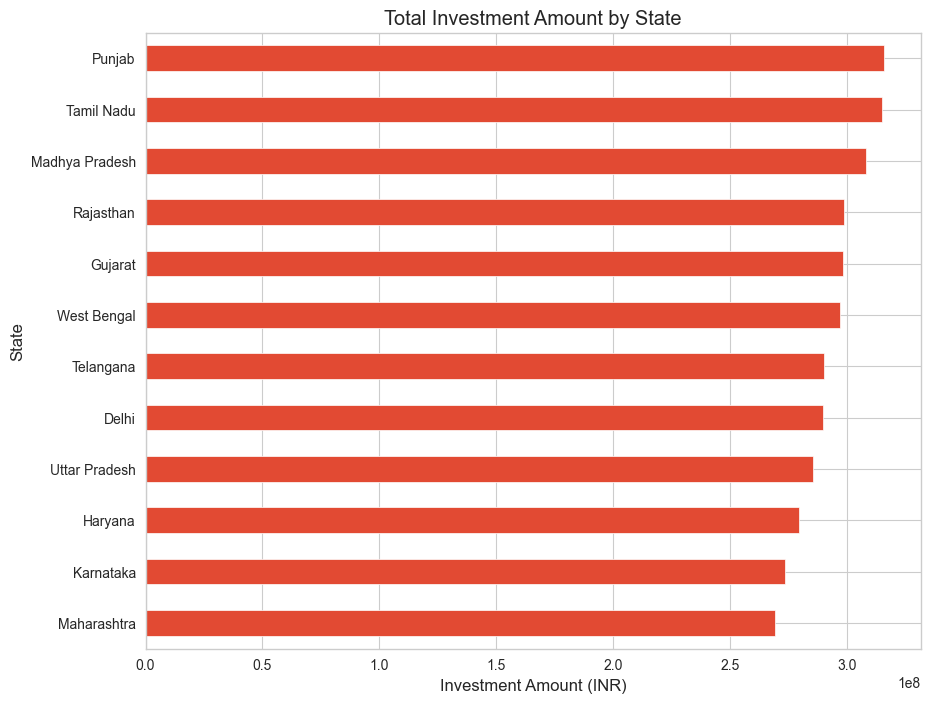

In [12]:
state_investment = transactions.groupby(
    "state"
)["amount_inr"].sum().sort_values()

plt.figure(figsize=(10,8))

state_investment.plot(kind="barh")

plt.title("Total Investment Amount by State")
plt.xlabel("Investment Amount (INR)")
plt.ylabel("State")

# Save chart
plt.savefig(
    "../reports/state_wise_investment.png",
    bbox_inches="tight"
)

plt.show()

### Insight

Investment activity is concentrated in a few states, suggesting regional differences in mutual fund adoption and financial awareness.

## Chart 9 :T30 vs B30 City Tier Distribution

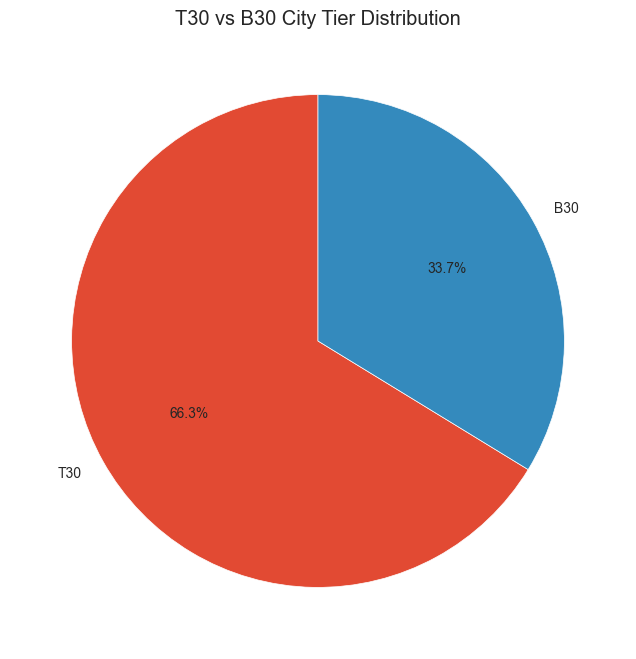

In [15]:
city_tier_dist = transactions["city_tier"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    city_tier_dist,
    labels=city_tier_dist.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("T30 vs B30 City Tier Distribution")

plt.savefig(
    "../reports/city_tier_distribution.png",
    bbox_inches="tight"
)

plt.show()

### Insight

T30 cities contribute a significant share of investments; however, B30 cities also represent a growing investor base, highlighting the expanding reach of mutual funds across India.

## Chart 10: Industry Folio Growth Analysis

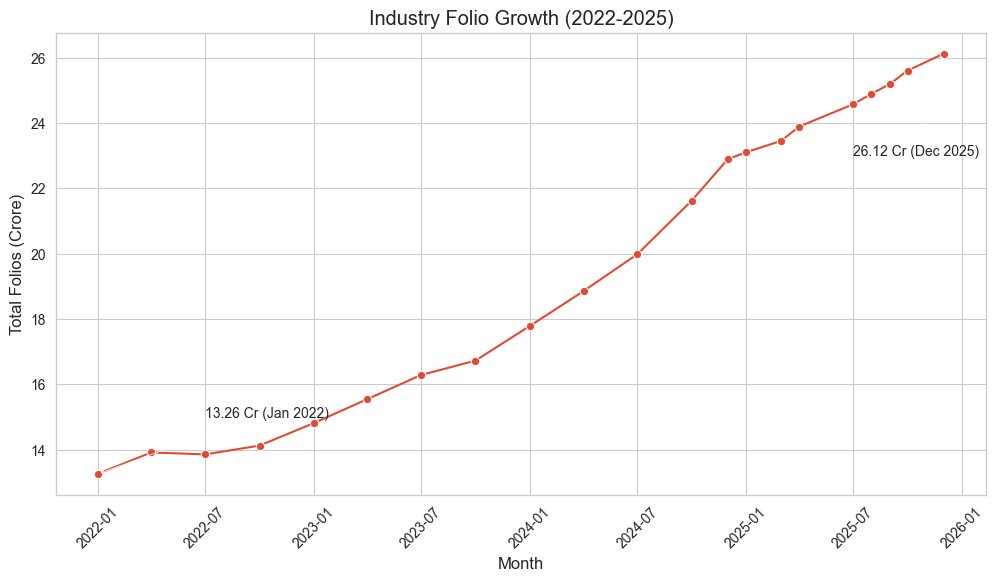

In [13]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=folios,
    x="month",
    y="total_folios_crore",
    marker="o"
)

plt.annotate(
    "13.26 Cr (Jan 2022)",
    xy=(folios.iloc[0]["month"], 13.26),
    xytext=(folios.iloc[2]["month"], 15),
    arrowprops=dict(arrowstyle="->")
)

plt.annotate(
    "26.12 Cr (Dec 2025)",
    xy=(folios.iloc[-1]["month"], 26.12),
    xytext=(folios.iloc[-5]["month"], 23),
    arrowprops=dict(arrowstyle="->")
)

plt.title("Industry Folio Growth (2022-2025)")
plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")

plt.xticks(rotation=45)

plt.savefig(
    "../reports/folio_growth.png",
    bbox_inches="tight"
)

plt.show()

### Insight

The total number of mutual fund folios nearly doubled between 2022 and 2025, indicating rapid growth in retail investor participation.

## Chart 11: NAV Return Correlation Analysis

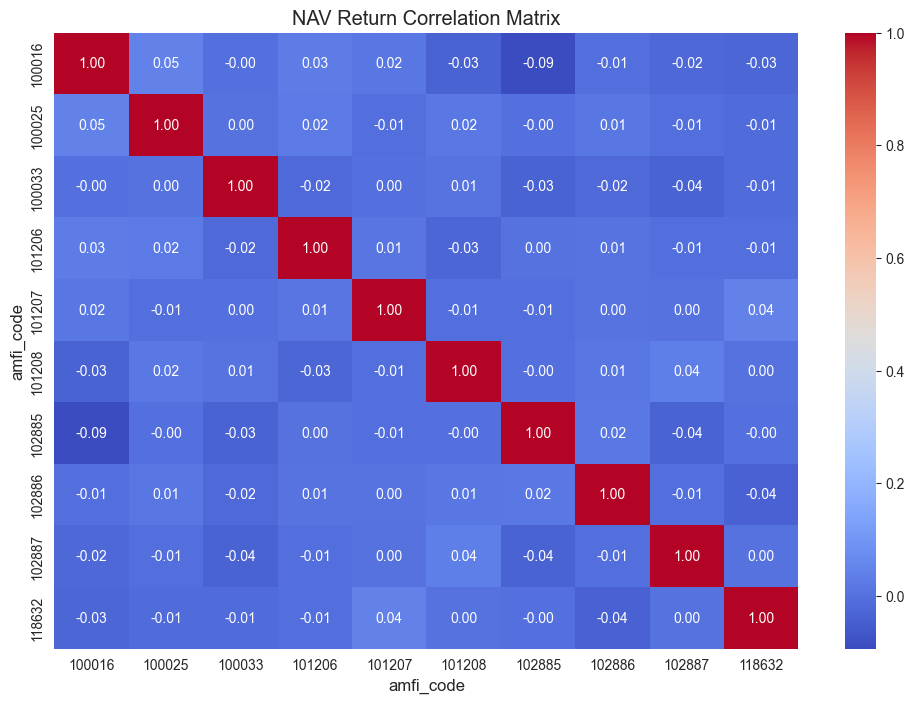

In [14]:
selected_funds = nav[
    nav["amfi_code"].isin(
        nav["amfi_code"].unique()[:10]
    )
]

pivot_nav = selected_funds.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

returns = pivot_nav.pct_change()

correlation_matrix = returns.corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("NAV Return Correlation Matrix")

plt.savefig(
    "../reports/nav_correlation_heatmap.png",
    bbox_inches="tight"
)

plt.show()

### Insight

Most mutual fund schemes exhibit strong positive correlations, indicating that fund performance is significantly influenced by overall market movements.

## Chart 12 :Sector Allocation Analysis

In [15]:
sector_weights = portfolio.groupby(
    "sector"
)["weight_pct"].sum()

fig = px.pie(
    values=sector_weights.values,
    names=sector_weights.index,
    hole=0.5,
    title="Sector Allocation Across Equity Funds"
)

fig.write_image(
    "../reports/sector_allocation_donut.png"
)

fig.show()

### Insight

Portfolio allocation is concentrated in a few key sectors, suggesting that equity funds prefer sectors with strong growth potential and market leadership.

## Chart 13 : Expense Ratio Distribution

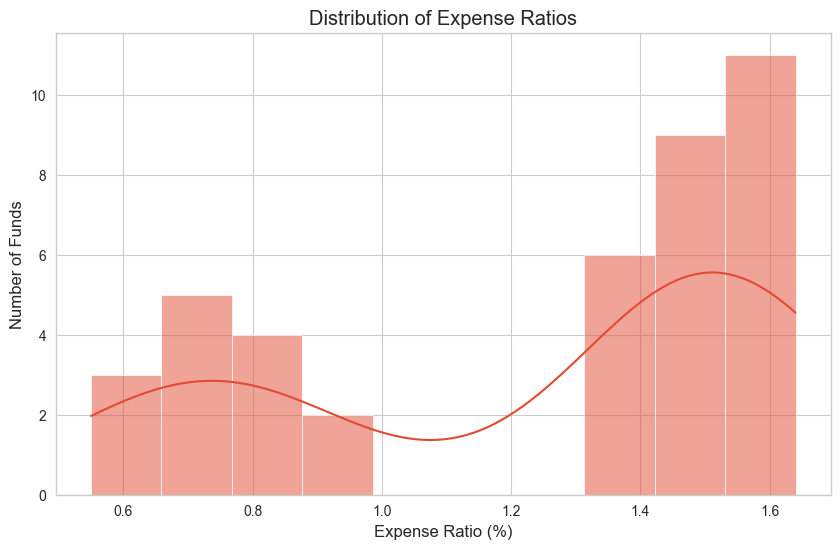

In [16]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=fund_master,
    x="expense_ratio_pct",
    bins=10,
    kde=True
)

plt.title("Distribution of Expense Ratios")
plt.xlabel("Expense Ratio (%)")
plt.ylabel("Number of Funds")

plt.savefig(
    "../reports/expense_ratio_distribution.png",
    bbox_inches="tight"
)

plt.show()

### Insight

Most mutual fund schemes have expense ratios clustered within a narrow range, indicating standardized pricing practices across fund houses.

## Chart 14 : Risk Category Distribution

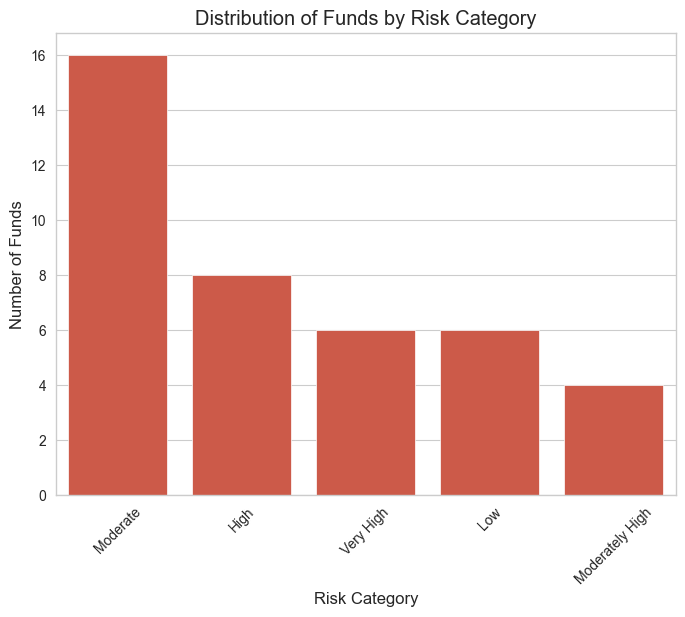

In [17]:
plt.figure(figsize=(8,6))

sns.countplot(
    data=fund_master,
    x="risk_category",
    order=fund_master["risk_category"].value_counts().index
)

plt.title("Distribution of Funds by Risk Category")
plt.xlabel("Risk Category")
plt.ylabel("Number of Funds")

plt.xticks(rotation=45)

plt.savefig(
    "../reports/risk_category_distribution.png",
    bbox_inches="tight"
)

plt.show()

### Insight

A large proportion of schemes belong to higher risk categories, reflecting the strong presence of equity-oriented mutual funds.

## Chart 15: Fund Category Distribution

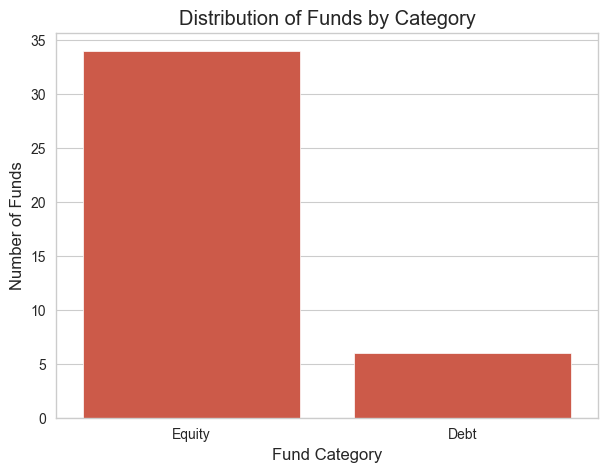

In [18]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=fund_master,
    x="category"
)

plt.title("Distribution of Funds by Category")
plt.xlabel("Fund Category")
plt.ylabel("Number of Funds")

plt.savefig(
    "../reports/fund_category_distribution.png",
    bbox_inches="tight"
)

plt.show()

### Insight

Equity funds dominate the dataset, highlighting the growing preference of investors towards equity-based investment products.

## Chart 16 : Payment Mode Distribution

In [1]:
payment_mode = transactions["payment_mode"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    payment_mode,
    labels=payment_mode.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Distribution of Payment Modes")

plt.savefig(
    "../reports/payment_mode_distribution.png",
    bbox_inches="tight"
)

plt.show()

NameError: name 'transactions' is not defined

### Insight

Digital payment methods account for a significant share of transactions, indicating increasing adoption of online investment platforms.